In [1]:
import scanpy as sc
adata = sc.read_h5ad('data_checkpoints/adata_po_QC_i_PCA.h5ad')

## 6. Graf sąsiedztwa i główna projekcja UMAP (Typy komórek)

Na podstawie wyselekcjonowanych głównych składowych (PCA) obliczamy graf sąsiedztwa (KNN), który posłuży do nieliniowej redukcji wymiarowości algorytmem UMAP. Następnie generujemy główną wizualizację przestrzeni 2D, kolorując komórki zgodnie z adnotacją uzyskananą wcześniej z modelu CellTypist.

In [ ]:
import scanpy as sc
import matplotlib.pyplot as plt
import os

os.makedirs('./figures', exist_ok=True)

print("Obliczanie grafu sąsiedztwa...")
sc.pp.neighbors(adata, n_neighbors=15, n_pcs=40, use_rep='X_pca')

print("Obliczanie współrzędnych UMAP...")
sc.tl.umap(adata)

#UMAP BEZ LABELI
print("Rysowanie UMAP bez labeli...")
sc.pl.umap(
    adata,
    color='cell_type',
    title='UMAP',
    legend_loc=None,
    show=False
)
sciezka_bez_labeli = './figures/UMAP_bez_labeli.png'
plt.savefig(sciezka_bez_labeli, dpi=300, bbox_inches='tight')
plt.close()
print(f"Zapisano: {sciezka_bez_labeli}")

print("Rysowanie UMAP z labelami...")
sc.pl.umap(
    adata,
    color='cell_type',
    title='UMAP – typy komórek (z labelami)',
    legend_loc='on data',
    legend_fontsize=8,
    legend_fontoutline=2, 
    show=False
)
sciezka_z_labelami = './figures/UMAP_z_labelami.png'
plt.savefig(sciezka_z_labelami, dpi=300, bbox_inches='tight')
plt.close()
print(f"Zapisano: {sciezka_z_labelami}")

Obliczanie grafu sąsiedztwa...
Obliczanie współrzędnych UMAP...
Rysowanie UMAP bez labeli...
Zapisano: ./figures/UMAP_bez_labeli.png
Rysowanie UMAP z labelami...
Zapisano: ./figures/UMAP_z_labelami.png


## 7. Klasteryzacja komórek (Porównanie: Leiden vs Louvain)

Przeprowadzamy bez nadzorowaną klasteryzację komórek za pomocą dwóch popularnych algorytmów grafowych: **Leiden** (uznawany za nowszy i dokładniejszy) oraz klasycznego **Louvain**. 
Testujemy różne wartości parametru `resolution` (0.3, 0.5, 0.8, 1.0), który decyduje o szczegółowości podziału (im wyższa rozdzielczość, tym więcej drobnych subpopulacji).

Obliczanie klastrów algorytmem Leiden...


/tmp/ipykernel_244049/3917440442.py:6: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(adata, resolution=res, key_added=f'leiden_{res}')


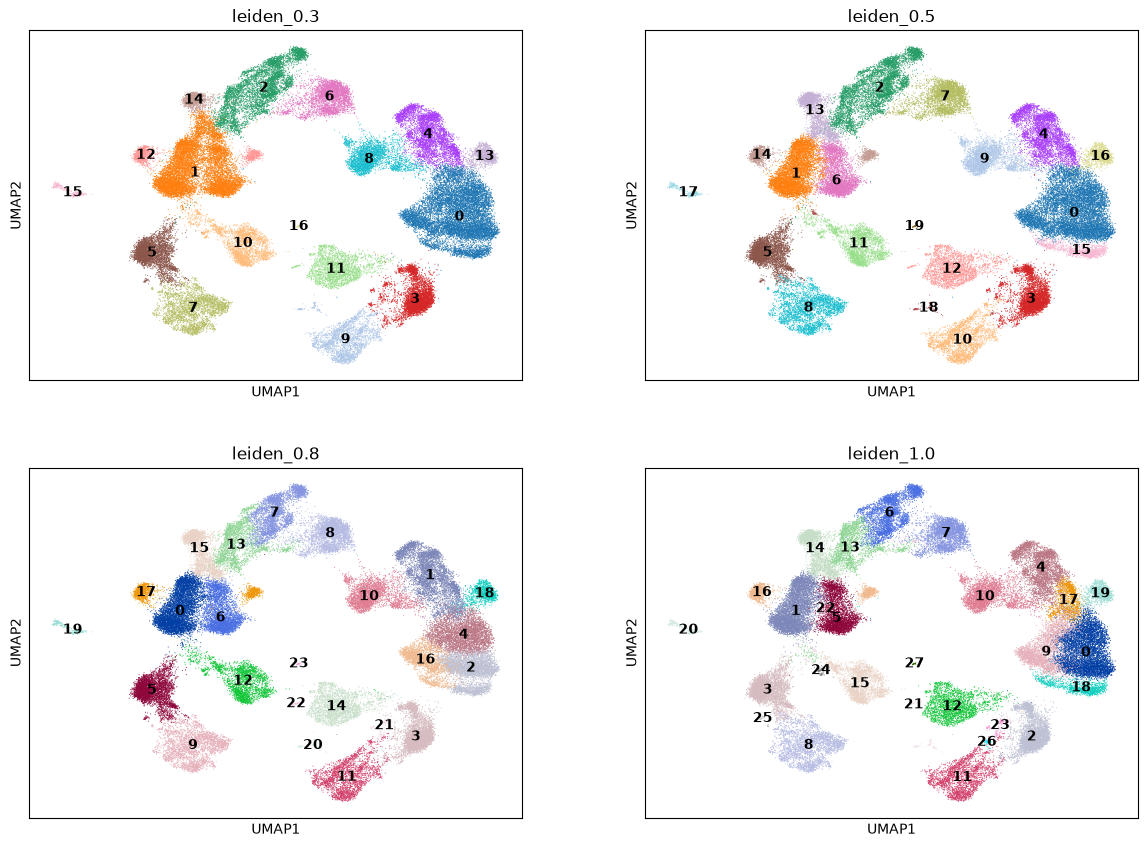

Obliczanie klastrów algorytmem Louvain...


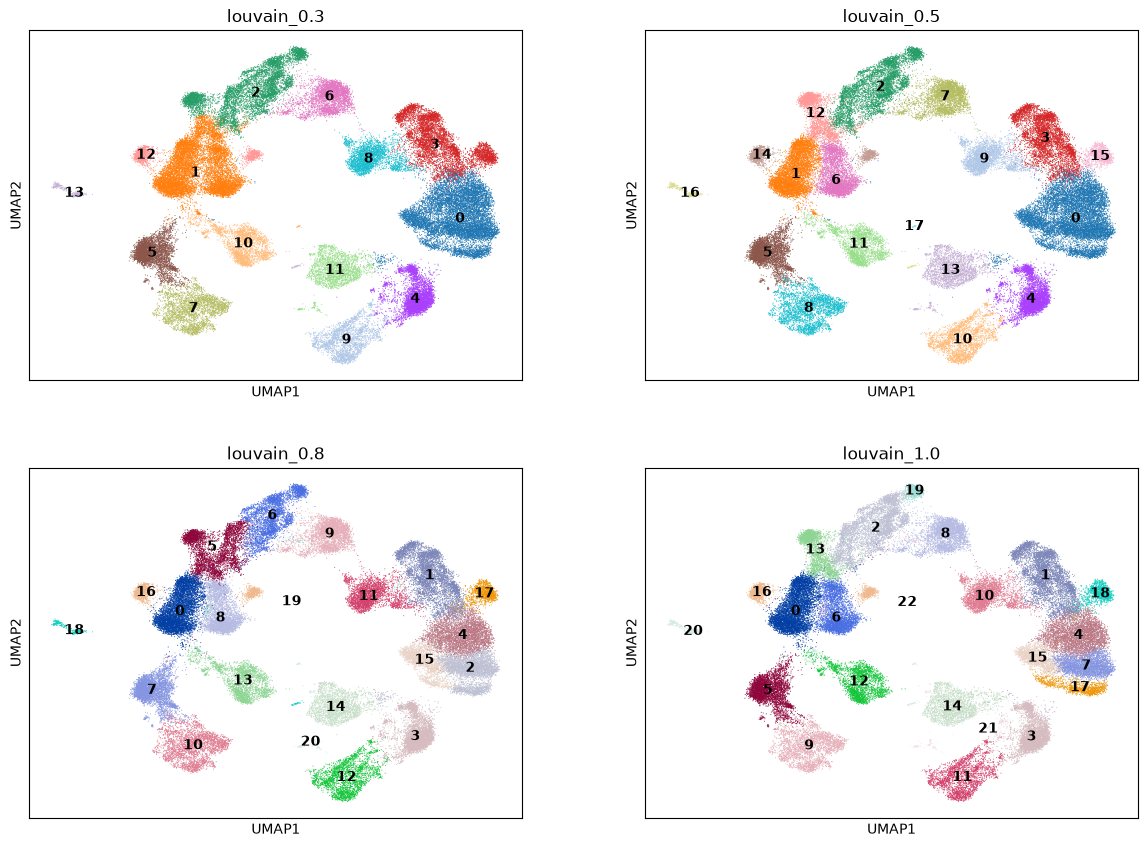

In [ ]:
resolutions = [0.3, 0.5, 0.8, 1.0]

#ALGORYTM LEIDEN
print("Obliczanie klastrów algorytmem Leiden...")
for res in resolutions:
    sc.tl.leiden(adata, resolution=res, key_added=f'leiden_{res}')

sc.pl.umap(
    adata, 
    color=[f'leiden_{res}' for res in resolutions], 
    ncols=2,
    legend_loc='on data',
    show=False
)
plt.savefig('./figures/porownanie_rozdzielczosci_leiden.png', dpi=300, bbox_inches='tight')
plt.show()


print("Obliczanie klastrów algorytmem Louvain...")
for res in resolutions:
    sc.tl.louvain(adata, resolution=res, key_added=f'louvain_{res}') 

sc.pl.umap(
    adata, 
    color=[f'louvain_{res}' for res in resolutions], 
    ncols=2,
    legend_loc='on data',
    show=False
)
plt.savefig('./figures/porownanie_rozdzielczosci_louvain.png', dpi=300, bbox_inches='tight')
plt.show()

## 8. Wizualizacja UMAP w podziale na próbki (Split UMAP)

Aby wizualnie ocenić zjawisko tzw. "batch effect" oraz sprawdzić, czy konkretne warunki (np. stymulacja / mikrograwitacja) wywołują powstawanie specyficznych subpopulacji, generujemy macierz wykresów UMAP osobno dla każdej z 8 próbek. 
Komórki pochodzące z innych próbek stanowią wyszarzone tło, co ułatwia orientację topograficzną.

Generowanie macierzy wykresów UMAP dla poszczególnych próbek...


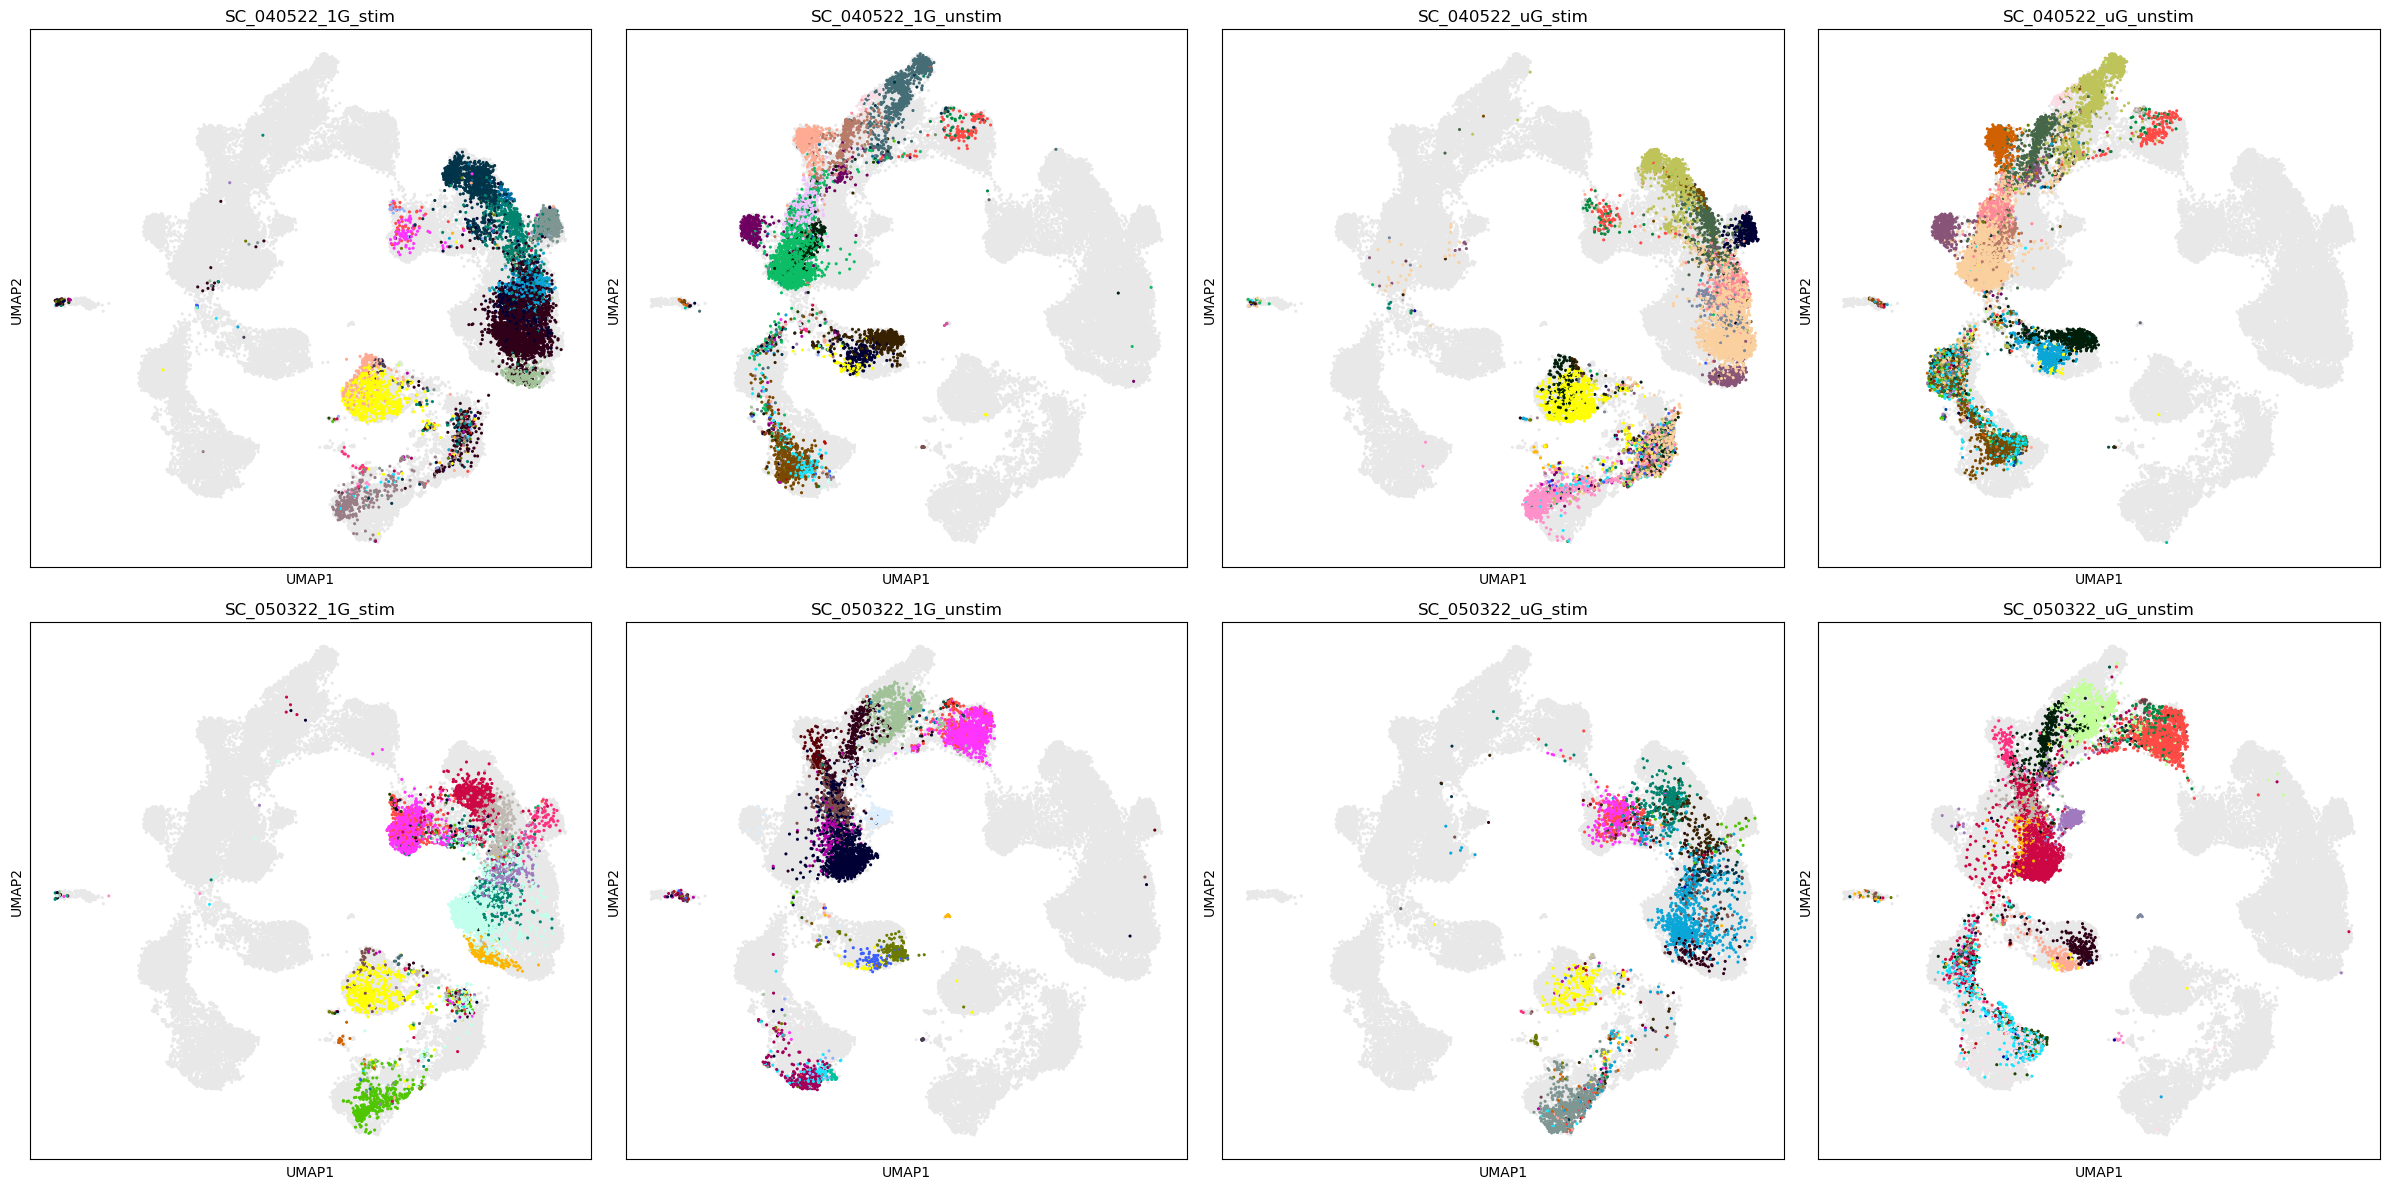

In [ ]:
print("Generowanie macierzy wykresów UMAP dla poszczególnych próbek...")

probki = adata.obs['sample_id'].unique()
fig, axes = plt.subplots(2, 4, figsize=(24, 12))
axes = axes.flatten()

for i, probka in enumerate(probki):
    adata.obs['tmp_plot'] = adata.obs['cell_type'].astype(str)
    adata.obs.loc[adata.obs['sample_id'] != probka, 'tmp_plot'] = np.nan
    adata.obs['tmp_plot'] = adata.obs['tmp_plot'].astype('category')
    
    if 'cell_type_colors' in adata.uns:
        adata.uns['tmp_plot_colors'] = adata.uns['cell_type_colors']

    sc.pl.umap(
        adata, 
        color='tmp_plot',
        ax=axes[i],
        show=False,
        title=probka,
        size=20,
        legend_loc='none',
        na_color='#e8e8e8'
    )

handles, labels = axes[0].get_legend_handles_labels()
if handles:
    clean_handles, clean_labels = [], []
    for h, l in zip(handles, labels):
        if l != 'nan':
            clean_handles.append(h)
            clean_labels.append(l)
    fig.legend(clean_handles, clean_labels, loc='center right', bbox_to_anchor=(1.12, 0.5), frameon=False, fontsize=12)

plt.tight_layout()
plt.savefig('./figures/8_probek_UMAP.png', dpi=300, bbox_inches='tight')
plt.show()
del adata.obs['tmp_plot']
if 'tmp_plot_colors' in adata.uns:
    del adata.uns['tmp_plot_colors']

## 10. Analiza korelacji między próbkami (Pseudobulk PCA)

Aby ocenić globalne podobieństwo między próbkami oraz sprawdzić, jak układają się one względem warunków grawitacyjnych (1G vs uG), przeprowadzono analizę korelacji Pearsona. 
Dla każdej próbki uśredniono jej profil w przestrzeni głównych składowych (PCA), a następnie porównano próbki między sobą, tworząc hierarchicznie klastrowane mapy ciepła (Clustermap). Analizę przeprowadzono w podziale na warunki stymulacji.

Obliczanie i rysowanie macierzy korelacji próbek...


/tmp/ipykernel_197412/2709149159.py:24: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  corr_matrix = df_pca.groupby('sample_id').mean().T.corr()


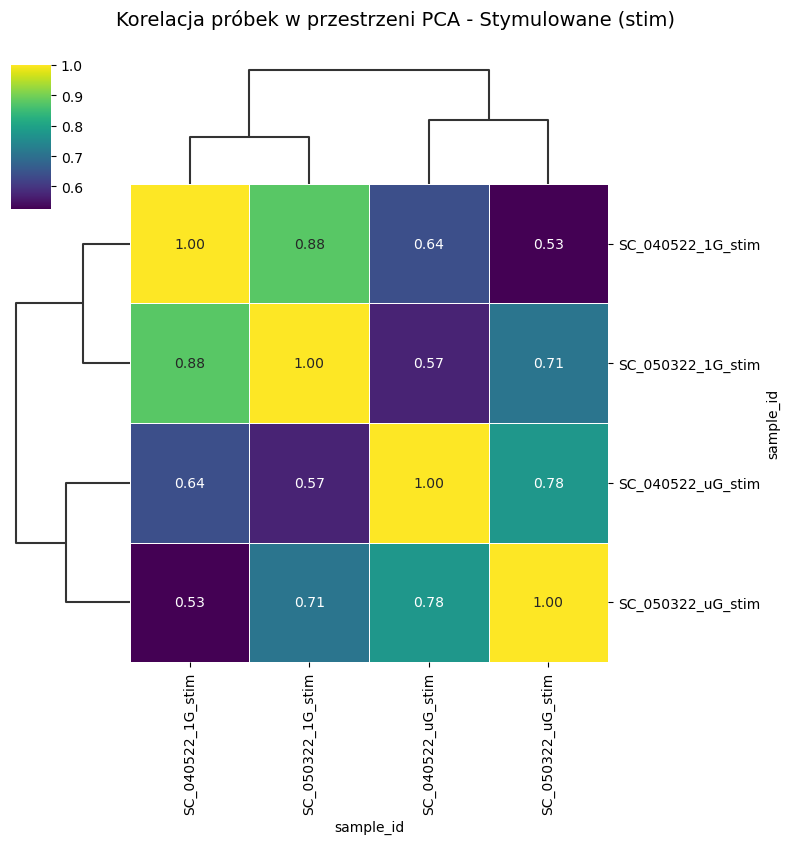

Zapisano wykres do: ./figures/korelacja_stim.png



/tmp/ipykernel_197412/2709149159.py:24: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  corr_matrix = df_pca.groupby('sample_id').mean().T.corr()


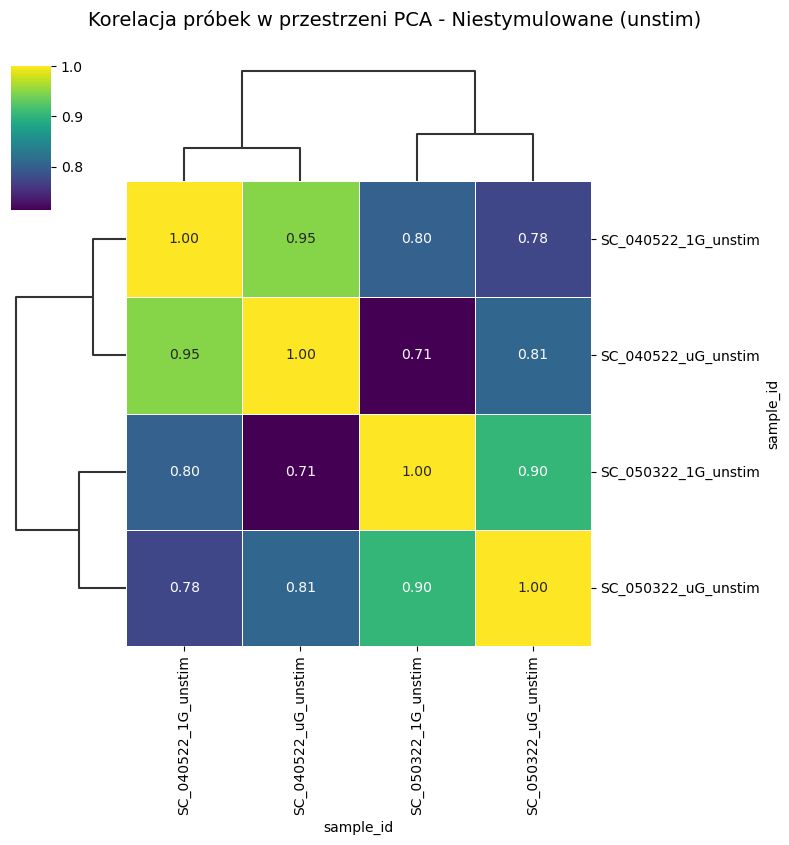

Zapisano wykres do: ./figures/korelacja_unstim.png



In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os

os.makedirs('./figures', exist_ok=True)

print("Obliczanie i rysowanie macierzy korelacji próbek...")

warunki_stymulacji = ['stim', 'unstim']
etykiety_tytulow = {'stim': 'Stymulowane (stim)', 'unstim': 'Niestymulowane (unstim)'}

for status in warunki_stymulacji:
    # 1. Filtrujemy dane tylko do obecnego statusu stymulacji
    adata_subset = adata[adata.obs['stimulation'] == status].copy()
    
    # 2. Wyciągamy macierz PCA i przypisujemy ID próbek
    df_pca = pd.DataFrame(adata_subset.obsm['X_pca'])
    df_pca['sample_id'] = adata_subset.obs['sample_id'].values
    
    # 3. Obliczamy średni profil dla próbki i tworzymy macierz korelacji Pearsona
    corr_matrix = df_pca.groupby('sample_id').mean().T.corr()
    
    # 4. Rysujemy Clustermap
    g = sns.clustermap(
        corr_matrix, 
        cmap='viridis', 
        figsize=(8, 8), 
        annot=True,            
        fmt=".2f",            
        linewidths=0.5,       
        tree_kws={'linewidths': 1.5} 
    )
    
    g.fig.suptitle(f"Korelacja próbek w przestrzeni PCA - {etykiety_tytulow[status]}", y=1.05, fontsize=14)
    
    sciezka_zapisu = f'./figures/korelacja_{status}.png'
    plt.savefig(sciezka_zapisu, dpi=300, bbox_inches='tight')
    plt.show()
    
    print(f"Zapisano wykres do: {sciezka_zapisu}\n")